<a href="https://colab.research.google.com/github/kantichachu-bit/kanticha-website/blob/main/Copy_of_Lecture_14_Deployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# สื่อการสอน: การสร้าง บันทึก และ Deploy โมเดล Machine Learning ฉบับสมบูรณ์

**โดย:** ผู้ช่วยสอน (TA)

บทเรียนนี้จะพานักศึกษาเดินทางไปในโลกของ Machine Learning ตั้งแต่การสร้างโมเดล, การบันทึกเพื่อนำกลับมาใช้ใหม่, ไปจนถึงการสร้างเป็น API และนำขึ้นไปไว้บน Cloud เพื่อให้คนอื่นสามารถใช้งานได้จริงผ่านอินเทอร์เน็ต

**เนื้อหาในบทเรียน:**
1.  **Part 1: การสร้างและบันทึกโมเดล (Model Training & Persistence)**
    *   ฝึกสอนโมเดลจำแนกสายพันธุ์ดอกไอริส (Iris) ด้วย `scikit-learn`
    *   บันทึกและโหลดโมเดลด้วย `joblib`
2.  **Part 2: การสร้าง API ด้วย FastAPI**
    *   เรียนรู้การเปลี่ยนโมเดลให้กลายเป็นบริการ (Service) ที่เรียกใช้งานได้
    *   เขียนโค้ด API ด้วย FastAPI เพื่อรับข้อมูลและส่งคืนผลการทำนาย
3.  **Part 3: การ Deploy API ขึ้น Hugging Face Spaces**
    *   เตรียมไฟล์สำหรับ Deploy (Dockerfile, requirements.txt)
    *   นำโปรเจกต์ของเราขึ้นไปโฮสต์บน Cloud ฟรีๆ ให้ทุกคนเข้าถึงได้
4.  **Part 4: การทดสอบ API ที่ Deploy แล้ว**
    *   เขียนโค้ด Python เพื่อเรียกใช้งาน API ของเราจากอินเทอร์เน็ต

---

## ส่วนที่ 1: การสร้างและบันทึกโมเดล

ขั้นตอนแรกคือการสร้างโมเดล Machine Learning ที่เราคุ้นเคย เราจะใช้ชุดข้อมูลดอกไอริสและโมเดล Random Forest ซึ่งเป็นโมเดลที่ให้ประสิทธิภาพดีและรวดเร็ว

In [ ]:
# 1.1 โหลด Library ที่จำเป็น
from sklearn.ensemble import RandomForestClassifier
from sklearn import datasets
from joblib import dump, load
import numpy as np

# 1.2 โหลดข้อมูล Iris
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Feature Names: {feature_names}")
print(f"Target Names: {target_names}")

# 1.3 สร้างและฝึกสอนโมเดล
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

print("\n✅ โมเดลผ่านการฝึกสอนเรียบร้อยแล้ว")

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names: ['setosa' 'versicolor' 'virginica']

✅ โมเดลผ่านการฝึกสอนเรียบร้อยแล้ว


#### 1.4 การบันทึกและโหลดโมเดลด้วย `joblib`

เมื่อโมเดลพร้อมใช้งาน เราจะบันทึกมันลงไฟล์ เพื่อให้สามารถนำกลับมาใช้ใหม่ได้โดยไม่ต้อง train ซ้ำ

In [ ]:
# บันทึกโมเดลลงไฟล์
model_filename = 'iris_random_forest.joblib'
dump(model, model_filename)

print(f"💾 โมเดลถูกบันทึกไว้ที่ไฟล์ '{model_filename}'")

# --- ลองโหลดโมเดลจากไฟล์กลับมาใช้งาน เพื่อพิสูจน์ว่ามันทำงานได้จริง ---

print("\n--- กำลังโหลดโมเดลกลับมา ---")
loaded_model = load(model_filename)

print(f"✅ โมเดลถูกโหลดจากไฟล์ '{model_filename}' เรียบร้อยแล้ว")

# สร้างข้อมูลตัวอย่างเพื่อทดสอบ (ดอก Setosa)
# [sepal length, sepal width, petal length, petal width]
new_data = [[5.1, 3.5, 1.4, 0.2], [2, 3.5, 1.4, 3] ,[5.1, 0.5, 1.4, 0.1]]

# ทำนายผลด้วยโมเดลที่โหลดมา
prediction = loaded_model.predict(new_data)


💾 โมเดลถูกบันทึกไว้ที่ไฟล์ 'iris_random_forest.joblib'

--- กำลังโหลดโมเดลกลับมา ---
✅ โมเดลถูกโหลดจากไฟล์ 'iris_random_forest.joblib' เรียบร้อยแล้ว


In [ ]:
prediction

array([0, 0, 0])

In [ ]:
predicted_class_name = target_names[prediction[0]]

print(f"\nข้อมูลใหม่สำหรับทดสอบ: {new_data}")
print(f"🧠 ผลการทำนาย: '{predicted_class_name}' (Index: {prediction[0]}) ")


ข้อมูลใหม่สำหรับทดสอบ: [[5.1, 3.5, 1.4, 0.2], [2, 3.5, 1.4, 3], [5.1, 0.5, 1.4, 0.1]]
🧠 ผลการทำนาย: 'setosa' (Index: 0) 


---

## ส่วนที่ 2: การสร้าง API ด้วย FastAPI

ตอนนี้เรามีไฟล์โมเดล `.joblib` แล้ว ขั้นตอนต่อไปคือการสร้าง "ประตู" หรือ API ให้แอปพลิเคชันอื่นสามารถส่งข้อมูลเข้ามาถาม และรับผลการทำนายกลับไปได้

เราจะใช้ Magic Command `%%writefile` เพื่อสร้างไฟล์ `.py` ขึ้นมาในระบบของ Colab/Jupyter โดยโค้ดนี้ **ไม่ได้ถูกรันในช่องนี้โดยตรง** แต่เป็นการ **สร้างไฟล์** เพื่อเอาไปใช้รันในขั้นตอนถัดไป

In [ ]:
%%writefile main.py

# main.api.py
# นี่คือไฟล์ที่จะใช้รันเป็น Web Server ของเรา

from fastapi import FastAPI
from pydantic import BaseModel
from joblib import load
import numpy as np

# สร้างแอป FastAPI พร้อมใส่ Metadata ที่สวยงาม
app = FastAPI(
    title="Iris Species Prediction API",
    description="An API to predict the species of Iris flowers. Created for educational purposes.",
    version="1.0.0"
)

# โหลดโมเดลที่ฝึกไว้
# โค้ดนี้จะทำงานเมื่อ Server เริ่มต้นขึ้น
try:
    model = load('iris_random_forest.joblib')
    target_names = ['setosa', 'versicolor', 'virginica']
except FileNotFoundError:
    model = None
    target_names = []

# กำหนดโครงสร้างข้อมูล Input ที่จะรับเข้ามาผ่าน API
class IrisData(BaseModel):
    sepal_length: float
    sepal_width: float
    petal_length: float
    petal_width: float

# สร้าง Endpoint พื้นฐานสำหรับทดสอบ
@app.get("/")
def read_root():
    return {"message": "Welcome to the Iris Prediction API! Go to /docs to see the documentation."}

# สร้าง Endpoint สำหรับการทำนาย (/predict)
# @app.post หมายถึงรับข้อมูลผ่าน HTTP POST method
@app.post("/predict")
def predict_iris(data: IrisData):
    if model is None:
        return {"error": "Model not found."}

    # แปลงข้อมูลจาก API เป็น numpy array ที่โมเดลเข้าใจ
    input_data = np.array([[
        data.sepal_length,
        data.sepal_width,
        data.petal_length,
        data.petal_width
    ]])

    # ทำนายผล
    prediction_index = model.predict(input_data)[0]
    predicted_class_name = target_names[prediction_index]

    # ส่งผลลัพธ์กลับไปในรูปแบบ JSON
    return {
        "input": data.dict(),
        "predicted_class_index": int(prediction_index),
        "predicted_class_name": predicted_class_name
    }

Writing main.py


ไฟล์ `main.api.py` ได้ถูกสร้างขึ้นแล้ว!

**วิธีรัน API บนเครื่อง (Local):**
1. ติดตั้ง Library ที่จำเป็น: `pip install "fastapi[all]"` Ex ตาม requirement files
2. เปิด Terminal หรือ Command Prompt
3. ไปที่ Directory ที่มีไฟล์ `main.py` และ `iris_random_forest.joblib`
4. รันคำสั่ง: `python -m uvicorn main:app --reload`
5. เปิดเว็บเบราว์เซอร์ไปที่ `http://127.0.0.1:8000/docs` เพื่อดูหน้าเอกสารและทดลอง API

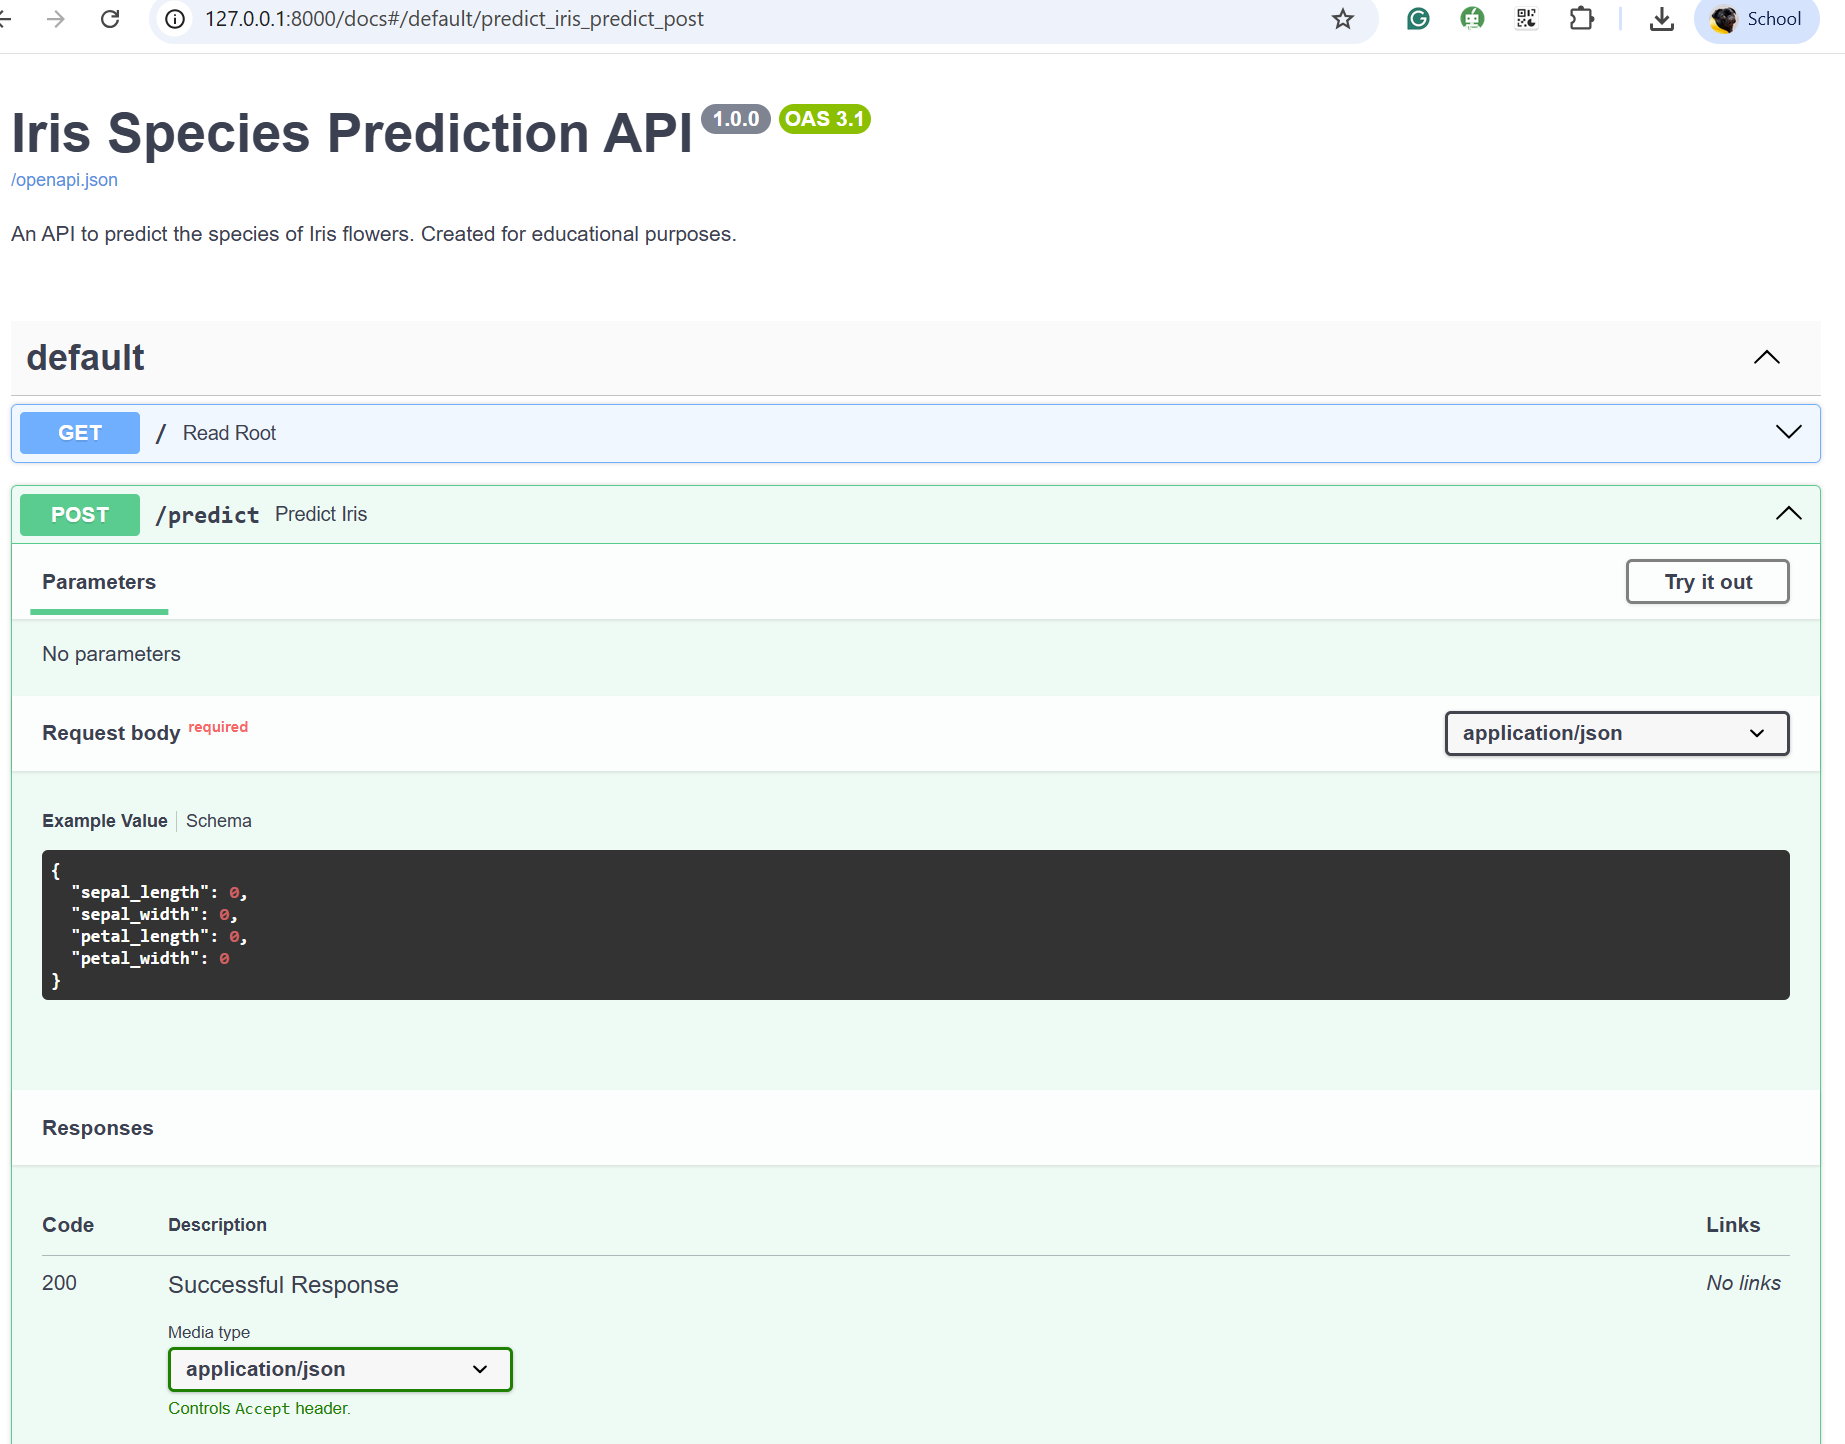

ทดลองปรับ  Request body  เพื่อส่งค่าอินพุทของการทำนาย

---

## ส่วนที่ 3: การ Deploy API ขึ้น Hugging Face Spaces

ถึงเวลาที่น่าตื่นเต้นที่สุด! เราจะนำไฟล์ทั้งหมดขึ้นไปไว้บนอินเทอร์เน็ต เพื่อให้ทุกคนสามารถใช้งานได้ เราต้องเตรียมไฟล์อีก 2 ไฟล์คือ `requirements.txt` และ `Dockerfile`

 * ใช้ฟรีไม่ได้แล้ว  ให้ดูตัวอย่างใหม่ที่


https://colab.research.google.com/drive/1MUoHZxVUT-L0MCD7EGuz18jXndDY7rOo?usp=sharing

**********************************************************************

#### 3.1 สร้างไฟล์ `requirements.txt`
ไฟล์นี้จะบอก Hugging Face ว่าโปรเจกต์ของเราต้องใช้ Library อะไรบ้าง

In [ ]:
# ใช้ %%writefile เพื่อสร้างไฟล์ requirements.txt
%%writefile requirements.txt
fastapi==0.111.0
uvicorn==0.30.1
scikit-learn==1.6.1
joblib==1.4.2
numpy==1.26.4
pydantic==2.7.4

Writing requirements.txt


#### 3.2 สร้างไฟล์ `Dockerfile`
ไฟล์นี้คือ "คู่มือการสร้าง" ที่จะบอก Hugging Face ว่าต้องตั้งค่าสภาพแวดล้อมและรันแอปของเราอย่างไร

In [ ]:
# ใช้ %%writefile เพื่อสร้างไฟล์ Dockerfile
%%writefile Dockerfile

# 1. ใช้ base image ของ Python 3.9
FROM python:3.9-slim

# 2. ตั้งค่า working directory ใน container
WORKDIR /code

# 3. คัดลอกไฟล์ requirements.txt เข้าไปก่อน
COPY ./requirements.txt /code/requirements.txt

# 4. ติดตั้ง dependencies จากไฟล์ requirements.txt
RUN pip install --no-cache-dir --upgrade -r /code/requirements.txt

# 5. คัดลอกไฟล์โค้ดและโมเดลทั้งหมดเข้าไป
COPY . /code/

# 6. บอกให้ Container เปิด Port 80 รอรับการเชื่อมต่อ
EXPOSE 80

# 7. คำสั่งสำหรับรันแอปพลิเคชันของเรา  ใช้ PORT  7860  ซึ่งเป็น defaul port ของ Hugging face Space
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "7860"]

Writing Dockerfile


#### 3.3 ขั้นตอนการสร้างและอัปโหลดไฟล์บน Hugging Face

ตอนนี้เรามีไฟล์ครบ 4 ไฟล์แล้ว:
1. `main.api.py`
2. `iris_random_forest.joblib`
3. `requirements.txt`
4. `Dockerfile`

**ขั้นตอนต่อไป ให้ทำตามนี้:**

1.  **ไปที่ [huggingface.co](https://huggingface.co)**, สมัครสมาชิก และ Login ให้เรียบร้อย
2.  คลิกที่รูปโปรไฟล์ขวาบน > เลือก **New Space**
3.  **ตั้งค่า Space:**
    *   **Space name:** ตั้งชื่อเท่ๆ (เช่น `my-first-ml-api`)
    *   **License:** เลือก `mit`
    *   **Select the Space SDK:** เลือก **`Docker`** และเลือก **`Blank`** (สำคัญมาก!)
    *   **Space hardware:** เลือก `CPU basic` (ฟรี)
    *   คลิก **`Create Space`**
4.  **อัปโหลดไฟล์:**
    *   เมื่อ Space ถูกสร้างแล้ว ให้ไปที่แท็บ **Files**
    *   คลิก **`+ Contribute`** > **`Upload files`**
    *   ลากไฟล์ทั้ง 4 ไฟล์ที่เราสร้างไว้ (จากทางซ้ายมือใน Colab หรือจากในเครื่อง) มาวาง
    *   ใส่ `Commit message` (เช่น "Initial project files") แล้วคลิก **`Commit changes to main`**

5.  **รอ...**
    *   Hugging Face จะเริ่มกระบวนการ `Building` โดยอัตโนมัติ (สามารถดู Log ได้ที่แท็บ `Logs`)
    *   เมื่อสถานะเปลี่ยนเป็น **`Running`** ก็หมายความว่า API ของเราพร้อมใช้งานแล้ว!

---

## ส่วนที่ 4: การทดสอบ API ที่ Deploy แล้ว

เมื่อ API ของเราออนไลน์แล้ว เราสามารถเขียนโค้ด Python เพื่อทดสอบเรียกใช้งานได้จากทุกที่ รวมถึงจาก Notebook นี้ด้วย! เราจะใช้ Library `requests` เพื่อส่งข้อมูลไปที่ API ของเรา

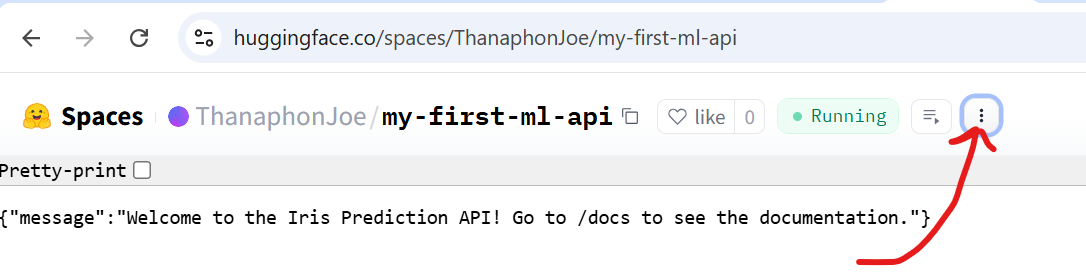

กดที่กล่องตามลูกศรข้างต้น  -> Embed this Space  แล้วทำการคัดลอก  Direct URL  

In [ ]:
import requests
import json

# ---------------------------------------------------- #
# ‼️ ให้นักศึกษาเปลี่ยน URL นี้เป็น URL ของตัวเอง ‼️
# ---------------------------------------------------- #
# SpaceURL  : https://huggingface.co/spaces/ThanaphonJoe/my-first-ml-api  ->
# Direct URL: "https://thanaphonjoe-my-first-ml-api.hf.space/"
# "https://thanaphonjoe-api1.hf.space"
# https://thanaphonjoe-foo.hf.space

hf_space_url = "https://thanaphonjoe-foo.hf.space"

# ตรวจสอบว่า URL ถูกต้องหรือไม่
if "YOUR_USERNAME" in hf_space_url:
    print("🛑 กรุณาเปลี่ยน hf_space_url เป็น URL ของ Hugging Face Space ของคุณก่อนรันเซลล์นี้")
else:
    # กำหนด Endpoint ที่เราต้องการทดสอบ
    predict_endpoint = f"{hf_space_url}/predict"

    # ข้อมูลที่เราจะส่งไป (เหมือนกับข้อมูลทดสอบใน Part 1)
    test_data = {
        "sepal_length": 5.1,
        "sepal_width": 3.5,
        "petal_length": 1.4,
        "petal_width": 0.2
    }

    print(f"🚀 กำลังส่งข้อมูลไปที่: {predict_endpoint}")
    print(f"📦 ข้อมูลที่ส่ง: {json.dumps(test_data, indent=2)}")

    try:
        # ส่ง Request แบบ POST ไปยัง API
        response = requests.post(predict_endpoint, json=test_data)
        response.raise_for_status() # เช็คว่ามี Error หรือไม่ (เช่น 404, 500)

        # แสดงผลลัพธ์ที่ได้รับกลับมา
        result = response.json()
        print("\n✨ ได้รับผลลัพธ์กลับมาแล้ว:")
        print(json.dumps(result, indent=2))

    except requests.exceptions.RequestException as e:
        print(f"\n❌ เกิดข้อผิดพลาดในการเชื่อมต่อ: {e}")

🚀 กำลังส่งข้อมูลไปที่: https://thanaphonjoe-foo.hf.space/predict
📦 ข้อมูลที่ส่ง: {
  "sepal_length": 5.1,
  "sepal_width": 3.5,
  "petal_length": 1.4,
  "petal_width": 0.2
}

✨ ได้รับผลลัพธ์กลับมาแล้ว:
{
  "input": {
    "sepal_length": 5.1,
    "sepal_width": 3.5,
    "petal_length": 1.4,
    "petal_width": 0.2
  },
  "predicted_class_index": 0,
  "predicted_class_name": "setosa",
  "Joob": 1233
}


### ตัวอย่าง

In [ ]:
import requests
import json

hf_space_url = "https://thanaphonjoe-my-first-ml-api.hf.space/"

# กำหนด Endpoint ที่เราต้องการทดสอบ
predict_endpoint = f"{hf_space_url}/predict"

# ข้อมูลที่เราจะส่งไป (เหมือนกับข้อมูลทดสอบใน Part 1)
test_data = {
    "sepal_length": 5.1,
    "sepal_width": 3.5,
    "petal_length": 1.4,
    "petal_width": 0.2
}

print(f"🚀 กำลังส่งข้อมูลไปที่: {predict_endpoint}")
print(f"📦 ข้อมูลที่ส่ง: {json.dumps(test_data, indent=2)}")

try:
    # ส่ง Request แบบ POST ไปยัง API ที่ Deploy ไว้
    response = requests.post(predict_endpoint, json=test_data)

    # เช็คว่ามี Error หรือไม่ (เช่น 404, 500)
    # ถ้า status code ไม่ใช่ 2xx จะเกิด Exception
    response.raise_for_status()

    # แสดงผลลัพธ์ที่ได้รับกลับมา
    result = response.json()
    print("\n✨ ได้รับผลลัพธ์กลับมาแล้ว:")
    print(json.dumps(result, indent=2, ensure_ascii=False))

except requests.exceptions.RequestException as e:
    print(f"\n❌ เกิดข้อผิดพลาดในการเชื่อมต่อ: {e}")


🚀 กำลังส่งข้อมูลไปที่: https://thanaphonjoe-my-first-ml-api.hf.space//predict
📦 ข้อมูลที่ส่ง: {
  "sepal_length": 5.1,
  "sepal_width": 3.5,
  "petal_length": 1.4,
  "petal_width": 0.2
}

✨ ได้รับผลลัพธ์กลับมาแล้ว:
{
  "input": {
    "sepal_length": 5.1,
    "sepal_width": 3.5,
    "petal_length": 1.4,
    "petal_width": 0.2
  },
  "predicted_class_index": 0,
  "predicted_class_name": "setosa"
}


In [ ]:
result

{'input': {'sepal_length': 5.1,
  'sepal_width': 3.5,
  'petal_length': 1.4,
  'petal_width': 0.2},
 'predicted_class_index': 0,
 'predicted_class_name': 'setosa'}

In [ ]:
### สร้างลิสต์ของรูปภาพ เพื่อทำการแสดงผลการทำนาย

import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io # Needed to handle in-memory image data

# The headers are correct and necessary
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

setodsaURL  = 'https://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg'
versicolorURL  = 'https://daylily-phlox.eu/wp-content/uploads/2016/08/Iris-versicolor-1.jpg'
virginicaURL  = 'https://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg'
figs = []
urls = [setodsaURL, versicolorURL, virginicaURL]

for url in urls:
  try:
    # 2. Use requests.get() with headers to download the image data
    response = requests.get(url, headers=headers)
    response.raise_for_status() # Raise an exception for bad status codes (like 404 or 403)

    # 3. Create an in-memory binary stream from the downloaded content
    image_bytes = io.BytesIO(response.content)

    # 4. Open the image directly from memory and convert to a NumPy array
    image = Image.open(image_bytes)
    figs.append(np.asarray(image))

    print(f"Successfully processed image from: {url}")

  except requests.exceptions.RequestException as e:
    print(f"Could not download {url}. Error: {e}")


Successfully processed image from: https://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg
Successfully processed image from: https://daylily-phlox.eu/wp-content/uploads/2016/08/Iris-versicolor-1.jpg
Successfully processed image from: https://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg


## ทำการแก้ไขโค้ด ด้านล่าง ให้ใช้งาน API ในการประมวลผล

ผลการพยากรตัวแบบจากข้อมูลวัด [[6.  4.  6.  0.1]] คือกล้วยไม้สายพันธ์ุ เติมให้หน่อย


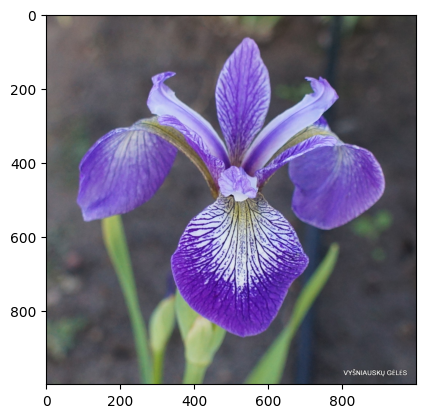

In [ ]:
  # สร้าง slider bar เพื่อทำการรับอินพุท
sepal_length = 6  #@param {type: "slider", min: 4, max: 8}
sepal_width  = 4  #@param {type: "slider", min: 1, max: 6}
petal_length = 6  #@param {type: "slider", min: 1, max: 8}
petal_width  = 0.1  #@param {type: "slider", min: 0.1, max: 3}
inputX = np.array([[sepal_length,sepal_width,petal_length,petal_width]]) # input feature required 2D array
predictIndex = 1  # แก้ไขให้ถูกต้อง
predictVal = "เติมให้หน่อย"
print(f'ผลการพยากรตัวแบบจากข้อมูลวัด {inputX} คือกล้วยไม้สายพันธ์ุ {predictVal}')
plt.imshow(figs[predictIndex])

## สรุป

เยี่ยมมาก! ในบทเรียนนี้ เราได้เดินทางตั้งแต่ต้นจนจบในกระบวนการนำโมเดล Machine Learning ไปใช้งานจริง:
1.  สร้างโมเดล `RandomForest` และบันทึกด้วย `joblib`
2.  สร้าง API ด้วย `FastAPI` เพื่อเป็น "ประตู" ให้โมเดล
3.  ใช้ `Dockerfile` และ `Hugging Face Spaces` เพื่อนำ API ของเราขึ้นไปอยู่บนโลกออนไลน์
4.  ทดสอบเรียกใช้งาน API ที่เรา Deploy เองจากโค้ด Python

ทักษะเหล่านี้เป็นพื้นฐานที่สำคัญมากสำหรับสายงาน Data Scientist และ Machine Learning Engineer ขอให้ทุกคนสนุกกับการสร้างโปรเจกต์ของตัวเองต่อไปครับ!